In [8]:
#Question 4.1
x = [1,2,3,10]
y= [10,20,30,40]

#Using zip
z = [a + b for a, b in zip(x, y)]

#Using map
def add(a, b):
    return a + b
z = list(map(add, x, y))

print(z)
print(k)

[11, 22, 33, 50]
[11, 22, 33, 50]


In [16]:
#PRactice
import numpy as np
colors = np.array(['red', 'blue', 'orange', 'green', 'white', 'black', 'cyan'])
indx = np.random.randint(0, len(colors), 3)
print ("Random numbers are :", indx)
print("Three random colors:", colors[indx])

Random numbers are : [5 5 1]
Three random colors: ['black' 'black' 'blue']


In [19]:
#Question 4.2
import numpy as np
throws = np.random.randint(1,7,size=200)
count = np.sum(throws==6)
print (f"Number of sixes : {count}")


Number of sixes : 41


In [28]:
%%writefile rps_game.py
#Question 4.3
import numpy as np

def play():
    moves = ['R','P','S']
    print ("R --> Rock, P --> Paper, S --> Scissors")
    user = input("Enter R, P or S:").upper()
    
    if user not in moves:
        print("Invalid input, Try again!")
        return
    comp_idx = np.random.randint(0, 3)
    computer = moves[comp_idx]
    print (f"You : {user} | Computer : {computer}")
    
    if user == computer:
        print("Tie!")
    elif (user,computer in [('R','S'),('P','R'),('S','P')]):
        print("You WIN!")
    else:
        print("Computerm WINS!")
play()

Overwriting rps_game.py


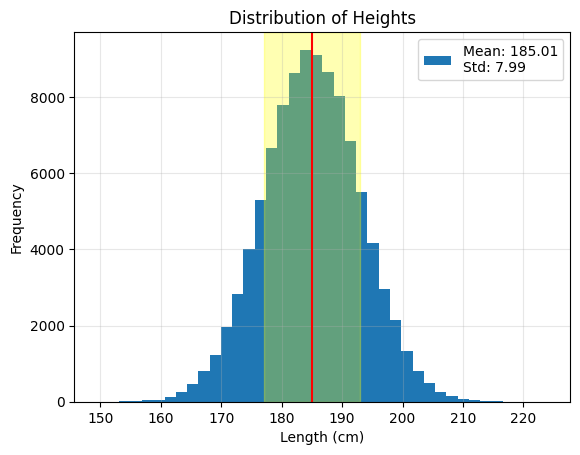

P(X <= 190): 0.7340144709512995
P(within 1 sigma): 0.6826894921370859


<Figure size 640x480 with 0 Axes>

In [56]:
#Question 4.4
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

data = np.random.normal(185, 8, 100000)
mu = np.mean(data)
sigma = np.std(data)

plt.hist(data, bins=40, label=f"Mean: {mu:.2f}\nStd: {sigma:.2f}")
plt.axvline(mu, color='red')
plt.axvspan(mu - sigma, mu + sigma, alpha=0.3, color='yellow')

plt.legend()
plt.grid(alpha =0.3)
plt.title('Distribution of Heights')
plt.xlabel('Length (cm)')
plt.ylabel('Frequency')
plt.show()
plt.savefig('height_distribution.png')

# Inputs
mu,sigma,h = 185,8,190

# X <= h
prob_h = ss.norm.cdf(h, mu, sigma)

# within 1sd
prob_1sigma = ss.norm.cdf(mu + sigma, mu, sigma) - ss.norm.cdf(mu - sigma, mu, sigma)

print(f"P(X <= {h}): {prob_h}")
print(f"P(within 1 sigma): {prob_1sigma}")

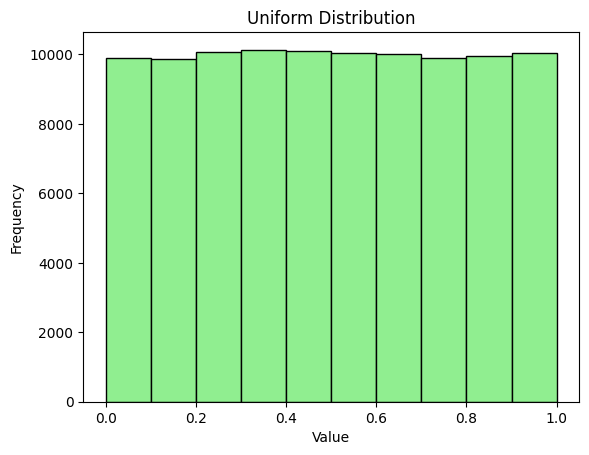

In [15]:
#Question 4.5
import numpy as np
import matplotlib.pyplot as plt

data = np.random.uniform(0, 1, 100000)

plt.hist(data, bins=10, color='lightgreen', edgecolor ='black')
plt.title('Uniform Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

In [6]:
%%writefile Monte_Carlo_Integral.py
#Question 4.6
import numpy as np

def mc_run():
    f = input("Enter function: ")
    a = float(input("Lower bound: "))
    b = float(input("Upper bound: "))
    
    x = np.random.uniform(a, b, 100000)
    y = eval(f)
    integral = (b - a) * np.mean(y)
    
    print(f"Result: {integral:.6f}")

mc_run()

Writing Monte_Carlo_Integral.py


In [ ]:

#NaN probable question 
'''It is not a number so np.nan == np.nan is False (typical question for an exam)

But it is an object and objects can be compared with operator is so np.nan is np.nan is True

'''


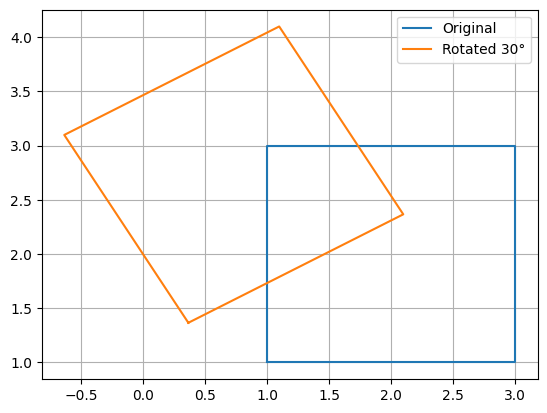

In [12]:
#Question 4.12
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 3, 3, 1, 1])
y = np.array([1, 1, 3, 3, 1])

theta = np.deg2rad(30)
rotor = np.cos(theta) + 1j * np.sin(theta)

z = x + 1j * y
z_rot = z * rotor

#PLot
plt.plot(x, y, label='Original')
plt.plot(z_rot.real, z_rot.imag, label='Rotated 30°')

plt.axis()
plt.grid()
plt.legend()
plt.show()

In [47]:
#Question 4.14
import numpy as np

def funcfilter(func, seq):
    arr = np.asarray(seq)
    
    filtered_arr = arr[arr > 0]
    return func(filtered_arr)

# Test1
sq = np.array([-100, -10, 0, 10, 100])
result_array = funcfilter(np.log10, sq)
print("Result log10:", result_array)

# Test2
n=100
result_single = funcfilter(np.log10, n)
print("Result log10:", result_single)


Result log10: [1. 2.]
Result log10: [2.]


In [ ]:
#Question 4.16
import numpy as np
from astropy.cosmology import Planck18

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

In [46]:
#Question 4.16
import numpy as np
from astropy.cosmology import Planck18
from scipy.integrate import quad

H0 = Planck18.H0.value  
Om0 = Planck18.Om0      
Ode0 = Planck18.Ode0    

def H(z):
    return H0 * np.sqrt(Om0 * (1 + z)**3 + Ode0)

def integrand(z):
    return 1 / ((1 + z) * H(z))

integral_result, error = quad(integrand, 0, 2)
print (integral_result)

#conversion factor from (1/ (km/s/Mpc)) to Gyr is roughly 977.8
conversion_factor = 977.8

t_L_gyr = integral_result * conversion_factor

print(f"Lookback time at z = 2: {t_L_gyr:.2f} Gyr")

0.010765276277273951
Lookback time at z = 2: 10.53 Gyr


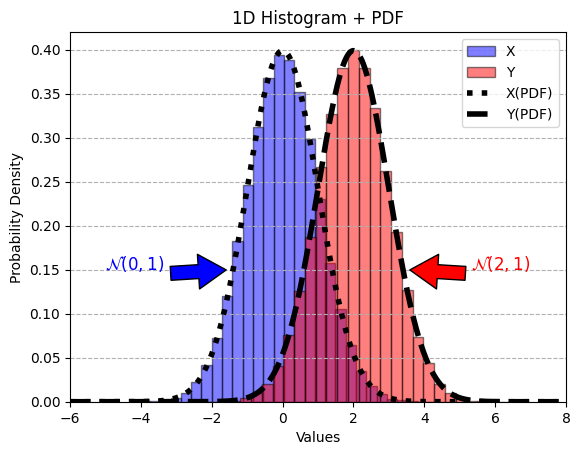

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 100000
x = np.random.normal(0, 1, n)
y = np.random.normal(2, 1, n)

# plot
plt.hist(x, bins=30, density=True, alpha=0.5, color='blue', edgecolor='black', label='X')
plt.hist(y, bins=30, density=True, alpha=0.5, color='red', edgecolor='black', label='Y')

x_range = np.linspace(-6, 8, 1000)
plt.plot(x_range, norm.pdf(x_range, 0, 1), 'k:', lw=4, label='X(PDF)')
plt.plot(x_range, norm.pdf(x_range, 2, 1), 'k--', lw=4, label='Y(PDF)')

plt.title('1D Histogram + PDF')
plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.xlim(-6, 8)
plt.ylim(0, 0.42)
plt.grid(axis='y', linestyle='--')
plt.legend()

plt.annotate(r'$\mathcal{N}(0,1)$', xy=(-1.5, 0.15), xytext=(-5, 0.15),
             arrowprops=dict(facecolor='blue', shrink=0.05,width=10,headwidth = 25, headlength = 20), color='blue', fontsize=12)

plt.annotate(r'$\mathcal{N}(2,1)$', xy=(3.5, 0.15), xytext=(7, 0.15),
             arrowprops=dict(facecolor='red', shrink=0.05,width=10,headwidth = 25, headlength = 20), color='red', fontsize=12, ha='right')

plt.show()

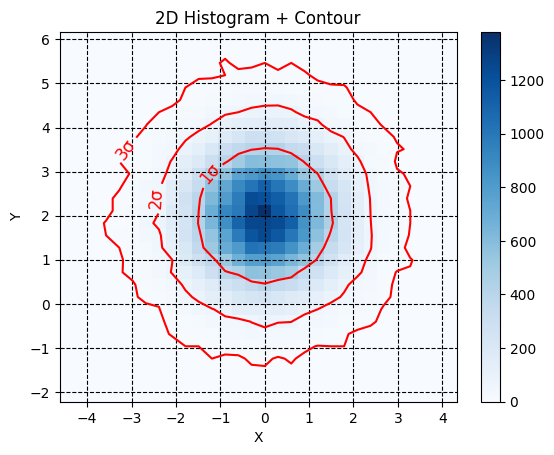

In [12]:
import numpy as np
import matplotlib.pyplot as plt

n = 100000
x = np.random.normal(0, 1, n)
y = np.random.normal(2, 1, n)

counts, xedges, yedges, image = plt.hist2d(x, y, bins=30, cmap='Blues')
plt.colorbar()

counts_flattened = np.sort(counts.flatten())[::-1]
dummy_counts = np.cumsum(counts_flattened)
levels = [counts_flattened[np.argwhere(dummy_counts <= frac * n)[-1][0]] 
          for frac in [0.68, 0.95, 0.997]]

# 4. Plot Contours
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
centers_x = (xedges[:-1] + xedges[1:]) / 2
centers_y = (yedges[:-1] + yedges[1:]) / 2

cs = plt.contour(centers_x, centers_y, counts.T, levels=levels[::-1], colors='red')
plt.clabel(cs, inline=True, fmt={levels[0]:'1σ', levels[1]:'2σ', levels[2]:'3σ'}, fontsize=12)

plt.title('2D Histogram + Contour')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(color='black', linestyle='--')
plt.show()